In [26]:
#loading python classes and packages
from string import punctuation
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import pickle
from nltk.stem import PorterStemmer
import PyPDF2
from PyPDF2 import PdfReader #use to read PDF documents
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint 
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [27]:
#defining dataset location
path = "Dataset"
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
ps = PorterStemmer()

In [28]:
#function to read data from given document file
def getContent(pdf):
    pdfReader = PyPDF2.PdfReader(pdf)
    text=''
    for i in range(0,3):
        pageObj = pdfReader.pages[i]
        text=text+pageObj.extract_text()
    return text

In [29]:
#function to clean journal pdf by removing stop words, stemming and lemmatization
def cleanText(doc):
    tokens = doc.split()
    table = str.maketrans('', '', punctuation)#remove punctuation
    tokens = [w.translate(table) for w in tokens]
    tokens = [word for word in tokens if word.isalpha()]#convert words to lowercase
    tokens = [w for w in tokens if not w in stop_words]#remove stop words
    tokens = [word for word in tokens if len(word) > 1]
    tokens = [ps.stem(token) for token in tokens]#apply stemming to clean word
    tokens = [lemmatizer.lemmatize(token) for token in tokens]#apply word lemmatization
    tokens = ' '.join(tokens)#merge all words
    return tokens #return process words

In [30]:
#if dataset already cleaned then load it
if os.path.exists("model/X.txt.npy"):
    with open('model/tfidf.txt', 'rb') as file:
        vectorizer = pickle.load(file)
    file.close()
    X = np.load("model/X.txt.npy")
    Y = np.load("model/Y.txt.npy")
    dataset = pd.read_csv("Jurnal.csv")
else: #if not process then process them
    for root, dirs, directory in os.walk(path):#loop all jurnal pdf files
        for j in range(len(directory)):
            name = os.path.basename(root)
            text = getContent(root+"/"+directory[j])#read pdf data
            label = 0
            if name == "predatory":#find lable as legitimate or predatory
                label = 1
            data.append([text, label]) #create dataset with pdf data and label
    data = pd.DataFrame(data, columns=['Journal_Text', 'Label'])  #save process data      
    data.to_csv("Jurnal.csv", index = False)#now load all journal process data and remove stp words
    textdata = []
    Y = []
    dataset = pd.read_csv("Jurnal.csv")
    for i in range(len(dataset)):
        article = dataset.get_value(i, 'Journal_Text')#read jounral data
        label = dataset.get_value(i, 'Label')
        if article is not None:
            article = article.strip().lower()
            article = cleanText(article)#clean text
            textdata.append(article)
            Y.append(label)
    #apply TFIDF vectorr        
    tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words, use_idf=True, ngram_range=(1, 1), smooth_idf=False, norm=None, decode_error='replace', max_features=768)
    tfidf = tfidf_vectorizer.fit_transform(textdata).toarray()        
    np.save("model/X.txt",tfidf)#save all process data
    with open('model/tfidf.txt', 'wb') as file:
        pickle.dump(tfidf_vectorizer, file)
    file.close()
    Y = np.asarray(Y)
    np.save("model/Y.txt",Y)
dataset    

,Journal_Text,Label
0,Neural Fitted Q Iteration - First Experiences\...,0
1,"35. R. N. Shepard, Psychon. Bull .Rev.1, 2 (19...",0
2,"Attend, Infer, Repeat:\nFast Scene Understandi...",0
3,Two/Too Simple Adaptations of Word2Vec for Syn...,0
4,HARP: Hierarchical Representation Learning for...,0
...,...,...
65,IEEE JOURNAL OF SELECTED TOPICS IN APPLIED EAR...,1
66,"Received 16 March 2023, accepted 10 April 2023...",1
67,IEEE EDUCATION SOCIETY SECTION\nReceived 30 Ap...,1
68,"Received 23 February 2023, accepted 4 March 20...",1


In [31]:
#display TFIDF vector values
print(X)

[[1.81450804 3.56551868 1.0588405  ... 0.         0.         0.        ]
 [0.         1.78275934 0.         ... 0.         0.         0.        ]
 [0.         0.         1.0588405  ... 2.25276297 0.         0.        ]
 ...
 [9.07254019 0.         1.0588405  ... 0.         0.         0.        ]
 [0.         0.         2.117681   ... 0.         0.         0.        ]
 [1.81450804 0.         1.0588405  ... 0.         0.         0.        ]]


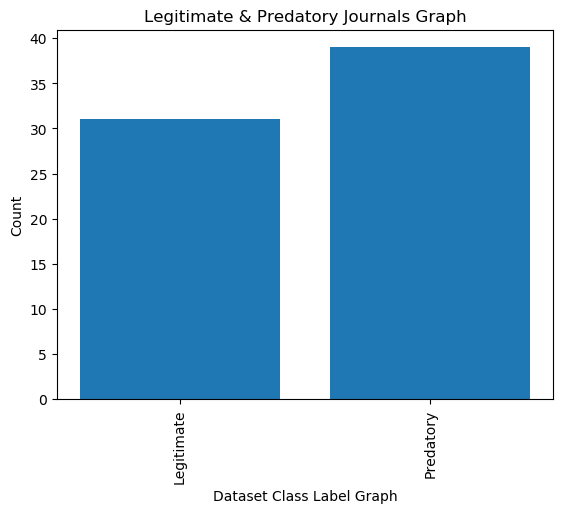

In [32]:
labels, count = np.unique(Y, return_counts=True)
labels = ['Legitimate', 'Predatory']
#plot graph of various class label images and its count
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.title("Legitimate & Predatory Journals Graph")
plt.xticks(rotation=90)
plt.show()

In [33]:
#preprocess dataset such as normalization and shuffling
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle dataset values
X = X[indices]
Y = Y[indices]
scaler = MinMaxScaler((0, 1))
X = scaler.fit_transform(X)#normalized values
print("Normalized TF-IDF values : "+str(X))

Normalized TF-IDF values : [[0.16666667 0.         0.16666667 ... 0.         0.         0.        ]
 [0.33333333 0.33333333 1.         ... 0.8        0.         0.        ]
 [0.         0.         0.16666667 ... 0.         0.         0.        ]
 ...
 [0.         1.         0.16666667 ... 0.         0.         0.        ]
 [0.16666667 0.         0.16666667 ... 0.         0.         0.        ]
 [0.         0.33333333 0.16666667 ... 0.4        0.         0.        ]]


In [34]:
#now splitting dataset into train & test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3) #split dataset into train and test
print()
print("Dataset train & test split as 80% dataset for training and 20% for testing")
print("Training Size (80%): "+str(X_train.shape[0])) #print training and test size
print("Testing Size (20%): "+str(X_test.shape[0]))
print()


Dataset train & test split as 80% dataset for training and 20% for testing
Training Size (80%): 49
Testing Size (20%): 21



In [50]:
precision = []
recall = []
fscore = []
accuracy = []

In [36]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100     
    print()
    print(algorithm+' Accuracy  : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FMeasure    : '+str(f))    
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.xticks(rotation=90)
    plt.show()


SVM Accuracy  : 100.0
SVM Precision   : 100.0
SVM Recall      : 100.0
SVM FMeasure    : 100.0


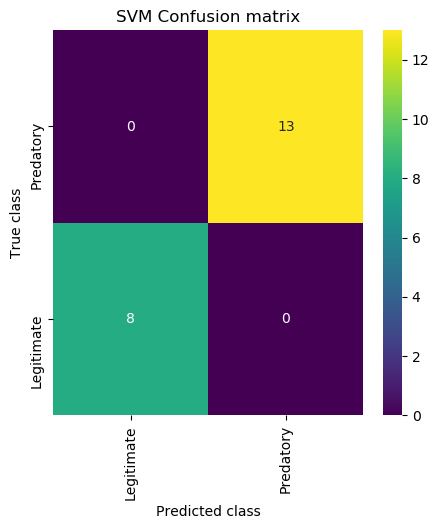

In [37]:
#train SVM algortihm on journal predatory dataset
param_grid = {'kernel': ['rbf'], 'C': [1]} #tuning parameters fro SVM
svm_cls = GridSearchCV(svm.SVC(), param_grid, cv=5)#with cross fold cv as 5
svm_cls.fit(X_train, y_train)#train svm 
predict = svm_cls.predict(X_test)#perfrom prediction on test data
calculateMetrics("SVM", predict, y_test)#calculate accuracy and other metrics


KNN Accuracy  : 47.61904761904761
KNN Precision   : 71.05263157894737
KNN Recall      : 57.692307692307686
KNN FMeasure    : 42.96296296296296


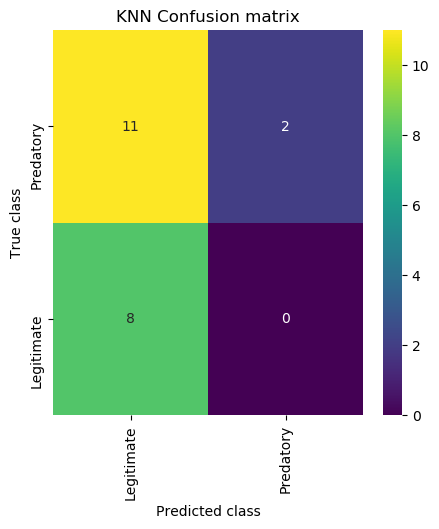

In [38]:
#train KNN algorithm
param_grid = {'n_neighbors': [1, 3, 5]}#tuning parameters fro SVM
knn_cls = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)#with cross fold cv as 5
knn_cls.fit(X_train, y_train)
predict = knn_cls.predict(X_test)#perfrom prediction on test data
calculateMetrics("KNN", predict, y_test)#calculate accuracy and other metrics


Neural Network Accuracy  : 100.0
Neural Network Precision   : 100.0
Neural Network Recall      : 100.0
Neural Network FMeasure    : 100.0


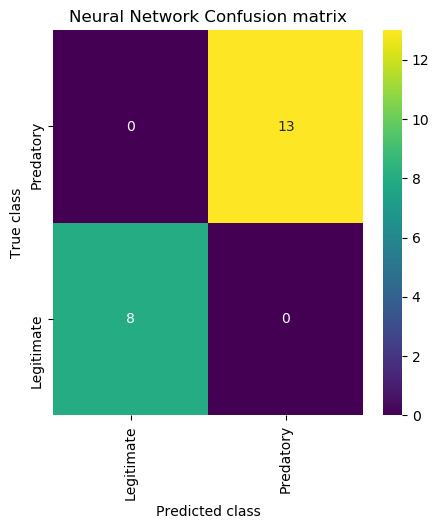

In [59]:
param_grid = {'activation': ['relu'], 'learning_rate_init': [0.01, 0.001], 'max_iter': [150, 180]} #tuning parameters fro neural network
#train neural network algorithm
nn_cls = GridSearchCV(MLPClassifier(), param_grid, cv=5)#with cross fold cv as 5
nn_cls.fit(X_train, y_train)
predict = nn_cls.predict(X_test)#perfrom prediction on test data
calculateMetrics("Neural Network", predict, y_test)#calculate accuracy and other metrics


CNN Accuracy  : 100.0
CNN Precision   : 100.0
CNN Recall      : 100.0
CNN FMeasure    : 100.0


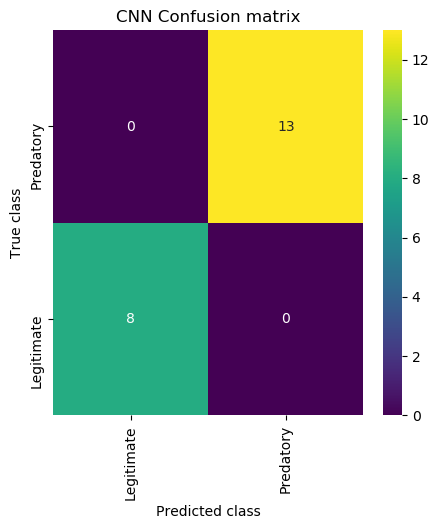

In [40]:
#now train CNN Algorithm
y_train1 = to_categorical(y_train)
y_test1  = to_categorical(y_test)
X_train1 = np.reshape(X_train, (X_train.shape[0], 16, 16, 3))
X_test1 = np.reshape(X_test, (X_test.shape[0], 16, 16, 3))
#defin CNN object
cnn_model = Sequential()
#add CNN layer with 32 neurons for features filtration
cnn_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
#max layer to collect filtered features from CNN layer
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
#defining another CNN layer
cnn_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
cnn_model.add(Flatten())
#defining output prediction layer
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train1.shape[1], activation = 'softmax'))
#compiling and training model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train1, y_train1, batch_size = 16, epochs = 10, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
#perform prediction on test data    
predict = cnn_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test1, axis=1)
calculateMetrics("CNN", predict, y_test1)#calculate accuracy and other metrics


rf Accuracy  : 100.0
rf Precision   : 100.0
rf Recall      : 100.0
rf FMeasure    : 100.0


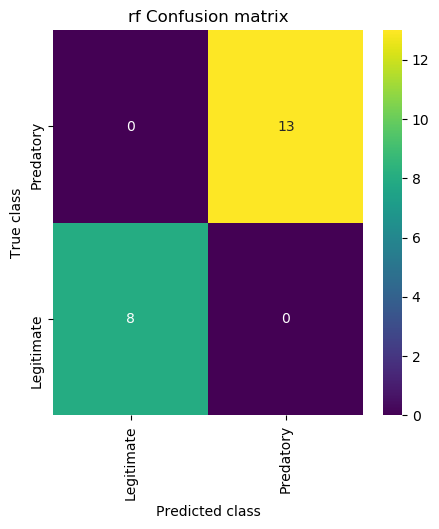

In [41]:
#train extension random forest algorithm as in propose work CNN is giving high accuracy but CNN is heavy in computation so
#we have added tuning parameters to traditional random forest algorithm to enhance its perfromnace and this algorithm also
#getting same accuracy as CNN but this will be lighter in execution compare to CNN
if os.path.exists('model/rf.txt'):
    with open('model/rf.txt', 'rb') as file:
        rf = pickle.load(file)
    file.close()
else:
    #defining tuning parameters for random forest
    param_grid = {'n_estimators': [50, 100, 150], 'criterion': ['gini', 'entropy'], 'max_depth': [1, 3, 5],
        'max_features': ['sqrt', 'log2']
    }
    #train random forest with tuned parameters
    rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)#with cross fold cv as 5
    rf.fit(X_train, y_train)
    with open('model/rf.txt', 'wb') as file:
        pickle.dump(rf, file)
    file.close()
predict = rf.predict(X_test)#perfrom prediction on test data
calculateMetrics("rf", predict, y_test)#calculate accuracy and other metrics

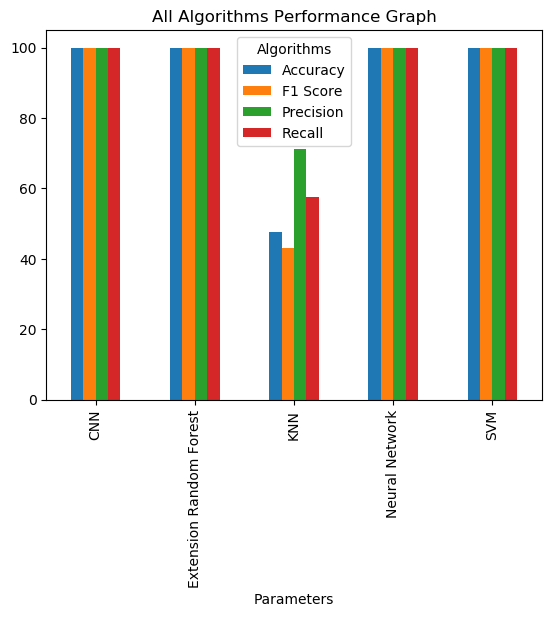

In [42]:
df = pd.DataFrame([['SVM','Precision',precision[0]],['SVM','Recall',recall[0]],['SVM','F1 Score',fscore[0]],['SVM','Accuracy',accuracy[0]],
                   ['KNN','Precision',precision[1]],['KNN','Recall',recall[1]],['KNN','F1 Score',fscore[1]],['KNN','Accuracy',accuracy[1]],
                   ['Neural Network','Precision',precision[2]],['Neural Network','Recall',recall[2]],['Neural Network','F1 Score',fscore[2]],['Neural Network','Accuracy',accuracy[2]],
                   ['CNN','Precision',precision[3]],['CNN','Recall',recall[3]],['CNN','F1 Score',fscore[3]],['CNN','Accuracy',accuracy[3]],
                   ['Extension Random Forest','Precision',precision[4]],['Extension Random Forest','Recall',recall[4]],['Extension Random Forest','F1 Score',fscore[4]],['Extension Random Forest','Accuracy',accuracy[4]],
                   
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("All Algorithms Performance Graph")
plt.show()

In [43]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","Precison","Recall","FScore","Accuracy"]
values = []
algorithm_names = ["SVM","KNN", "Neural Networks", "CNN", "Random Forest"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],precision[i],recall[i],fscore[i],accuracy[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,Precison,Recall,FScore,Accuracy
0,SVM,100.000000,100.000000,100.000000,100.000000
1,KNN,71.052632,57.692308,42.962963,47.619048
2,Neural Networks,100.000000,100.000000,100.000000,100.000000
3,CNN,100.000000,100.000000,100.000000,100.000000
4,Random Forest,100.000000,100.000000,100.000000,100.000000


In [63]:
#now predict predator journal from test PDF files
def predict(filename):
    text = getContent(filename)#read content from given PDF file
    text = text.strip().lower()
    text = cleanText(text)#clean PDF file by removing stop words
    content = []
    content.append(text)
    tfidf = vectorizer.transform([text]).toarray()#convert to TFIDF vector
    tfidf = scaler.transform(tfidf)#normalized TFIDF values
    predict = rf.predict(tfidf)#perform prediction on test data
    predict = predict[0]#get predicted value
    print(filename+" Journal Predicted as ====>"+labels[predict])#print predicted labels
  



In [45]:
predict("testJournals/paper1.pdf")#pass PDF as input for prediction

testJournals/paper1.pdf Journal Predicted as ====>Predatory


In [46]:
predict("testJournals/paper2.pdf")

testJournals/paper2.pdf Journal Predicted as ====>Legitimate


In [47]:
predict("testJournals/paper3.pdf")

testJournals/paper3.pdf Journal Predicted as ====>Predatory


In [48]:
predict("testJournals/paper4.pdf")

testJournals/paper4.pdf Journal Predicted as ====>Predatory
